In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/image-super-resolution/dataset/Raw Data/low_res/641.png
/kaggle/input/image-super-resolution/dataset/Raw Data/low_res/173.png
/kaggle/input/image-super-resolution/dataset/Raw Data/low_res/815.png
/kaggle/input/image-super-resolution/dataset/Raw Data/low_res/491.png
/kaggle/input/image-super-resolution/dataset/Raw Data/low_res/718.png
/kaggle/input/image-super-resolution/dataset/Raw Data/low_res/709.png
/kaggle/input/image-super-resolution/dataset/Raw Data/low_res/379.png
/kaggle/input/image-super-resolution/dataset/Raw Data/low_res/780.png
/kaggle/input/image-super-resolution/dataset/Raw Data/low_res/248.png
/kaggle/input/image-super-resolution/dataset/Raw Data/low_res/94.png
/kaggle/input/image-super-resolution/dataset/Raw Data/low_res/480.png
/kaggle/input/image-super-resolution/dataset/Raw Data/low_res/236.png
/kaggle/input/image-super-resolution/dataset/Raw Data/low_res/771.png
/kaggle/input/image-super-resolution/dataset/Raw Data/low_res/675.png
/kaggle/input/image-s

In [3]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D

In [4]:
train = os.listdir("/kaggle/input/image-super-resolution/dataset/train/low_res")
test = os.listdir("/kaggle/input/image-super-resolution/dataset/val/low_res")
print(f"number of images in the train set {len(train)}")
print(f"number of images in the val set {len(test)}")

number of images in the train set 685
number of images in the val set 170


(256, 256) (256, 256)


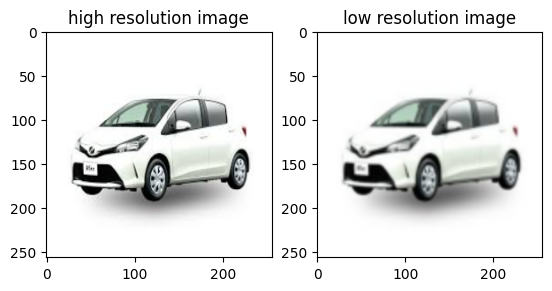

In [27]:
high = plt.imread("/kaggle/input/image-super-resolution/dataset/train/high_res/3.png")
low = plt.imread("/kaggle/input/image-super-resolution/dataset/train/low_res/3.png")
plt.subplot(121)
plt.imshow(high)
print(low.shape[:2], high.shape[:2])
plt.title("high resolution image")
plt.subplot(122)
plt.imshow(low)
plt.title("low resolution image")
plt.show()

Building The Classic 9-1-5 SRCNN Model

In [8]:
SRCNN_915 = Sequential([
    Conv2D(64, 9, padding='same', activation='relu', input_shape=(None, None, 3)),
    Conv2D(32, 1, padding='same', activation='relu'),
    Conv2D(3, 5, padding='same', activation='linear'),
    
])

load and preprocess the images

In [9]:
def load_image_pair(filename, low_dir, high_dir, target_size=(128,128)):
    low_path = os.path.join(low_dir, filename)
    high_path = os.path.join(high_dir, filename)

    low = cv2.imread(low_path)
    high = cv2.imread(high_path)

    # we are using openCV so we need to convert from BGR to RGB
    low = cv2.cvtColor(low, cv2.COLOR_BGR2RGB)
    high = cv2.cvtColor(high, cv2.COLOR_BGR2RGB)

    low = cv2.resize(low, target_size)
    high = cv2.resize(high, target_size)

    # normalize to [0,1]
    low = low.astype(np.float32) / 255.0
    high = high.astype(np.float32) / 255.0

    return low, high

Buidling the full Dataset

In [10]:
TRAIN_LOW = "/kaggle/input/image-super-resolution/dataset/train/low_res"
TRAIN_HIGH = "/kaggle/input/image-super-resolution/dataset/train/high_res"
VAL_LOW = "/kaggle/input/image-super-resolution/dataset/val/low_res"
VAL_HIGH = "/kaggle/input/image-super-resolution/dataset/val/high_res"

def build_dataset(filename, low_dir, high_dir, target_size=(128, 128)):
    X, Y = [], []
    for fname in filename:
        low, high = load_image_pair(fname, low_dir, high_dir, target_size)
        X.append(low)
        Y.append(high)
    return np.array(X), np.array(Y)

X_train, Y_train = build_dataset(train, TRAIN_LOW, TRAIN_HIGH)
X_val, Y_val = build_dataset(test, VAL_LOW, VAL_HIGH)

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}")    

Train shape: (685, 128, 128, 3), Validation shape: (170, 128, 128, 3)


In [12]:
def PSNR(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

def SSIM(y_true, y_pred):
    return tf.image.ssim(y_true, y_pred, max_val=1.0)

SRCNN_915.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss = 'mean_squared_error',
    metrics = [PSNR, SSIM]
)

SRCNN_915.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, None, None, 64) │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, None, None, 32) │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, None, None, 3)  │         2,403 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,099 (78.51 KB)

 Trainable params: 20,099 (78.51 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = SRCNN_915.fit(
    X_train, Y_train,
    validation_data = (X_val, Y_val),
    epochs = 50,
    batch_size = 16,
    verbose = 1
)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - loss: 0.1504 - psnr: 10.1255 - ssim: 0.2558 - val_loss: 0.0219 - val_psnr: 17.3440 - val_ssim: 0.5026
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - loss: 0.0183 - psnr: 18.0678 - ssim: 0.5230 - val_loss: 0.0151 - val_psnr: 18.9255 - val_ssim: 0.5658
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - loss: 0.0133 - psnr: 19.4553 - ssim: 0.5871 - val_loss: 0.0110 - val_psnr: 20.2761 - val_ssim: 0.6324
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - loss: 0.0098 - psnr: 20.8312 - ssim: 0.6601 - val_loss: 0.0079 - val_psnr: 21.7062 - val_ssim: 0.7005
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - loss: 0.0070 - psnr: 22.2970 - ssim: 0.7179 - val_loss: 0.0063 - val_psnr: 22.7337 - val_ssim: 0.7346
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - loss: 0.0055 - psnr: 23.3185 - ssim: 0.7442 - val_loss: 0.0053 - val_psnr: 23.5122 - val_ssim: 0.7607
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - loss: 0.0048 - psnr: 23.

plot the result and loss

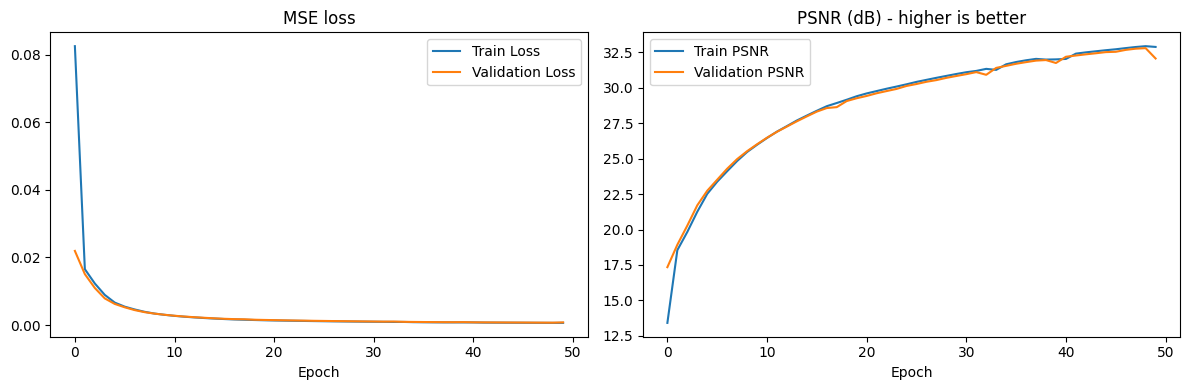

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MSE loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(122)
plt.plot(history.history['psnr'], label='Train PSNR')
plt.plot(history.history['val_psnr'], label='Validation PSNR')
plt.title('PSNR (dB) - higher is better')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

visualize result

In [25]:
def show_results(model, X, Y, num_images=3):
    preds = model.predict(X[:num_images])
    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4*num_images))
    for i in range(num_images):
        axes[i, 0].imshow(X[i])
        axes[i, 0].set_title("Low Resolution (Input)")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(np.clip(preds[i],0,1))
        axes[i, 1].set_title("SRCNN Output")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(Y[i])
        axes[i, 2].set_title("High Resolution (Ground Truth)")
        axes[i, 2].axis('off')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


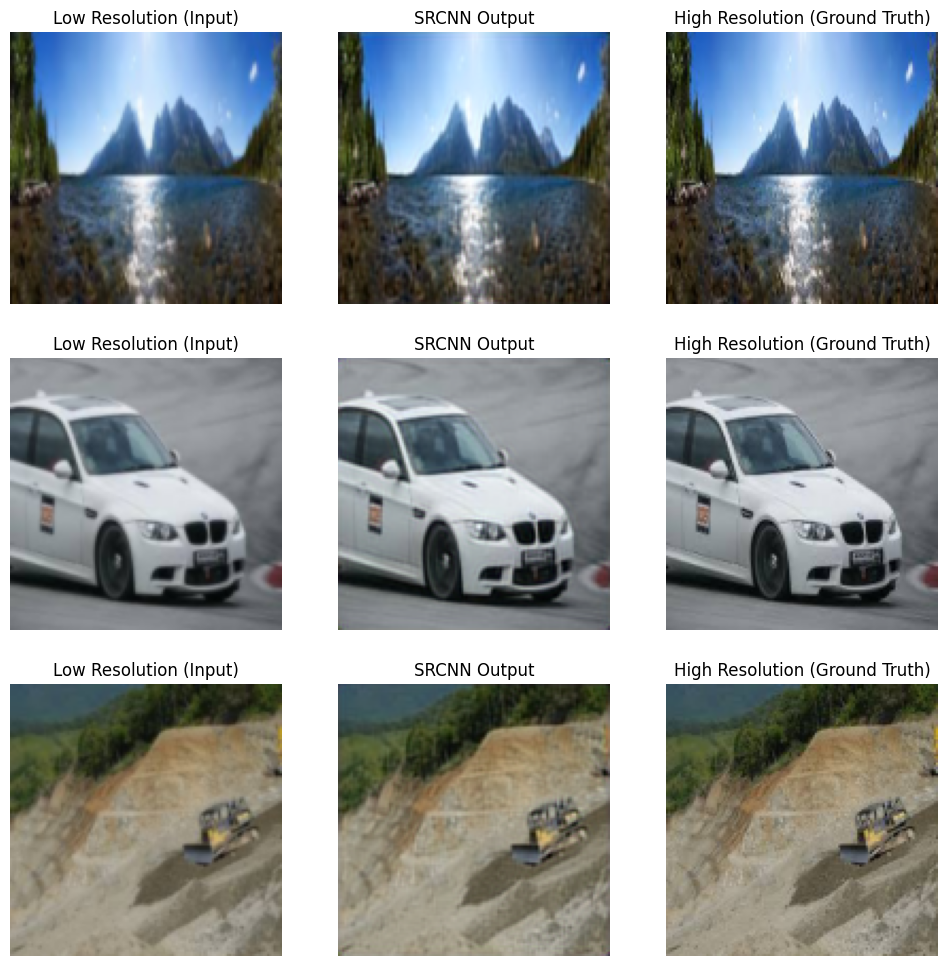

In [26]:
show_results(SRCNN_915, X_val, Y_val)